# Airplane Crash Fatalities Prediction

## Scenario 2: Regression

**Author:** *Maria Motter*
**Target Variable:** `Fatalities` (number of fatalities per crash)

This notebook applies the data science process to predict the number of fatalities in airplane crashes. The analysis includes data cleaning, feature engineering, model training, evaluation, and predictions on unseen data.


## Section 1: Introduction and Dataset Overview

### Problem Statement

This project uses historical airplane crash data to predict the number of fatalities (`Fatalities`) in an accident. Since the target is a numerical value, this is a regression problem.

### Goal

The aim is to build a model that can estimate the number of fatalities based on information about the crash, such as the number of people on board, aircraft type, location, and other available details. The final model will then be used to make predictions on an unseen dataset.

### Evaluation Metrics

Model performance is evaluated using:

* **R^2** – measures how well the model explains the variation in fatalities.
* **RMSE** – shows the average prediction error, giving more weight to large errors.
* **MAE** – shows the average prediction error in fatalities.

### Dataset Overview

The training dataset contains information about airplane crashes, including details such as date, location, aircraft type, number of people on board, and accident summaries. The target variable is **Fatalities**, which represents the number of people who died in each crash.

The unseen dataset contains the same features but does not include the `Fatalities` column, which is what the model will predict.


In [79]:
# library imports

import warnings
warnings.filterwarnings('ignore')   # keep the notebook output clean

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# global settings for reproducibility and consistent plots
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

In [80]:
# load datasets. 'latin1' encoding utilised because the files contain special characters

train = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_data.csv', encoding='latin1')
unseen = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_unseen.csv', encoding='latin1')

print('Training shape:', train.shape)
print('Unseen shape:', unseen.shape)

Training shape: (4741, 13)
Unseen shape: (527, 12)


In [81]:
# few rows of the training data
train.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
1,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
2,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
3,03/05/1915,01:00,"Tienen, Belgium",Military - German Navy,NaN,NaN,Zeppelin L-8 (airship),NaN,NaN,41.0,21.0,0.0,Crashed into trees while attempting to land af...
4,09/03/1915,15:20,"Off Cuxhaven, Germany",Military - German Navy,NaN,NaN,Zeppelin L-10 (airship),NaN,NaN,19.0,19.0,0.0,"Exploded and burned near Neuwerk Island, when..."


In [82]:
# few rows of the unseen data.
unseen.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Ground,Summary
0,10/24/2004,16:30,"Martinsville, Virginia",Private - Hendrick Motorsports Inc.,NaN,"Concord, NC - Martinsville, VA",Beech 200 Super King Air,N501RH,BB-805,10.0,0.0,The plane struck a steep incline in the Bull M...
1,08/09/1954,00:08,"Terceira Island, Azores, Portugal",AVIANCA,NaN,"Lajes, Azores - Bermuda",Lockheed 749A-79 Constellation,HK-163,2664,30.0,0.0,Crashed into mountains after poor weather dive...
2,12/02/1977,NaN,"Near Al Bayda, Lebanon",Balkan Bulgarian Airlines,NaN,Jeddah - Benghazi,Tupolev TU-154B,LZ-BTN,054,165.0,0.0,After not being able to land at the scheduled ...
3,11/02/1988,NaN,"Near Rzeszow, Poland",LOT Polish Airlines,703,Warszawa - Rzeszow,Antonov AN-24B,SP-LTD,67302209,29.0,0.0,The plane attempted to make an emergency landi...
4,08/15/1957,NaN,"Copenhagen, Denmark",Aeroflot,NaN,Riga - Copenhagen,Ilyushin IL-14P,CCCP-L1874,146000607,23.0,0.0,Crashed into the harbor after hitting the chim...


**Note:** there is no Fatalities column here.

In [83]:
# display column data types - training set
train.dtypes

Date             object
Time             object
Location         object
Operator         object
Flight #         object
Route            object
Type             object
Registration     object
cn/In            object
Aboard          float64
Fatalities      float64
Ground          float64
Summary          object
dtype: object

In [84]:
# stats summary - numeric columns training set
train.describe()

,Aboard,Fatalities,Ground
count,4722.000000,4730.000000,4721.000000
mean,27.721093,20.009725,1.766575
std,43.613847,33.142890,56.906906
min,0.000000,0.000000,0.000000
25%,5.000000,3.000000,0.000000
50%,13.000000,9.000000,0.000000
75%,30.000000,22.000000,0.000000
max,644.000000,583.000000,2750.000000


In [85]:
# stats summary - numeric columns unseen set
unseen.describe()

,Aboard,Ground
count,524.000000,525.000000
mean,26.053435,0.190476
std,37.898741,1.463912
min,1.000000,0.000000
25%,5.000000,0.000000
50%,14.000000,0.000000
75%,28.000000,0.000000
max,346.000000,20.000000


The summary statistics show that both `Fatalities` and `Aboard` are highly unbalanced. Most crashes involve relatively few people, while a small number involve very large losses. The `Ground` column is also mostly zero, with a few unusual high values. These patterns will be considered during the preprocessing stage.


## Section 2: Exploratory Data Analysis

This section explores the dataset to understand its structure, identify missing values, examine data types, and analyse the main features and target variable. The findings help guide the preprocessing and modelling stages.


In [86]:
# confirm shapes and data types
print('Training shape:', train.shape)
print('Unseen shape:', unseen.shape)
print()
print('Training dtypes:')
print(train.dtypes)

Training shape: (4741, 13)
Unseen shape: (527, 12)

Training dtypes:
Date             object
Time             object
Location         object
Operator         object
Flight #         object
Route            object
Type             object
Registration     object
cn/In            object
Aboard          float64
Fatalities      float64
Ground          float64
Summary          object
dtype: object


In [87]:
# count of missing values and percentages - training set (worst first)
missing = pd.DataFrame({
    'missing_count': train.isnull().sum(),
    'missing_pct': (train.isnull().mean() * 100).round(1)
}).sort_values('missing_pct', ascending=False)
missing

,missing_count,missing_pct
Flight #,3774,79.6
Time,2000,42.2
Route,1545,32.6
cn/In,1098,23.2
Summary,353,7.4
Registration,300,6.3
Type,24,0.5
Location,17,0.4
Aboard,19,0.4
Ground,20,0.4


**Finding:** The missing value analysis shows that several columns contain a large number of missing values, particularly `Flight #`, `Time`, `Route`, and `cn/In`. Some other columns, such as `Registration` and `Summary`, are not suitable for modelling due to their format and content. A small number of records are also missing values in the target variable (`Fatalities`), and these rows will be removed before model training.


In [88]:
# check exact duplicate rows - both files
print('Duplicate rows in training:', train.duplicated().sum())
print('Duplicate rows in unseen:', unseen.duplicated().sum())

Duplicate rows in training: 0
Duplicate rows in unseen: 0


In [89]:
# missing fatalities values
print('rows with missing Fatalities:', train['Fatalities'].isnull().sum())

rows with missing Fatalities: 11


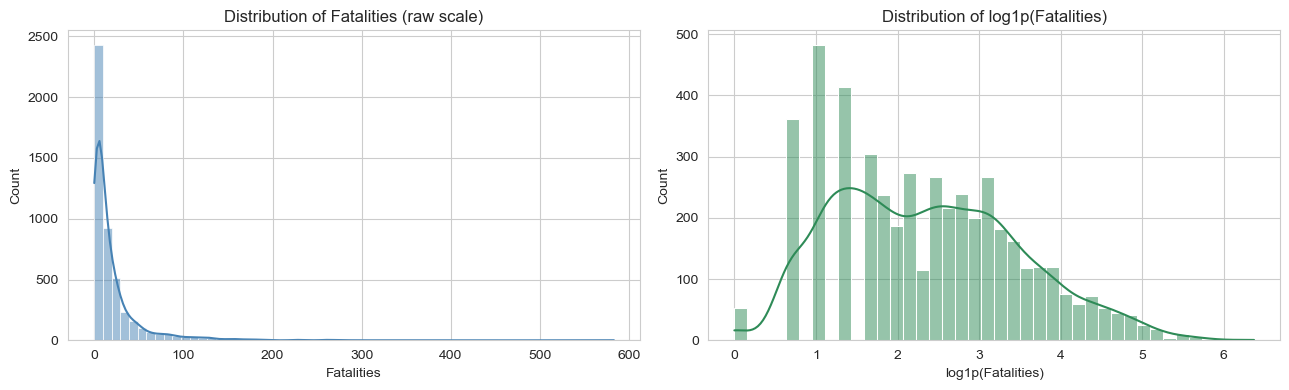

Skewness (raw): 4.996
Skewness (log1p): 0.363


In [90]:
# distribution of fatalities variable - histogram with a KDE overlay
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(train['Fatalities'].dropna(), bins=60, kde=True, color='steelblue', ax=ax[0])
ax[0].set_title('Distribution of Fatalities (raw scale)')
ax[0].set_xlabel('Fatalities')

# same distribution after a log1p transform
sns.histplot(np.log1p(train['Fatalities'].dropna()), bins=40, kde=True, color='seagreen', ax=ax[1])
ax[1].set_title('Distribution of log1p(Fatalities)')
ax[1].set_xlabel('log1p(Fatalities)')
plt.tight_layout()
plt.show()

print('Skewness (raw):', round(train['Fatalities'].dropna().skew(), 3))
print('Skewness (log1p):', round(np.log1p(train['Fatalities'].dropna()).skew(), 3))

**Finding:** The target variable (`Fatalities`) is highly right-skewed, with most crashes resulting in relatively few deaths and a small number resulting in very high fatalities. By applying a `log1p` transformation creates a more balanced distribution, thus helping the regression models learn more effectively and reducing the influence of extreme values during training.


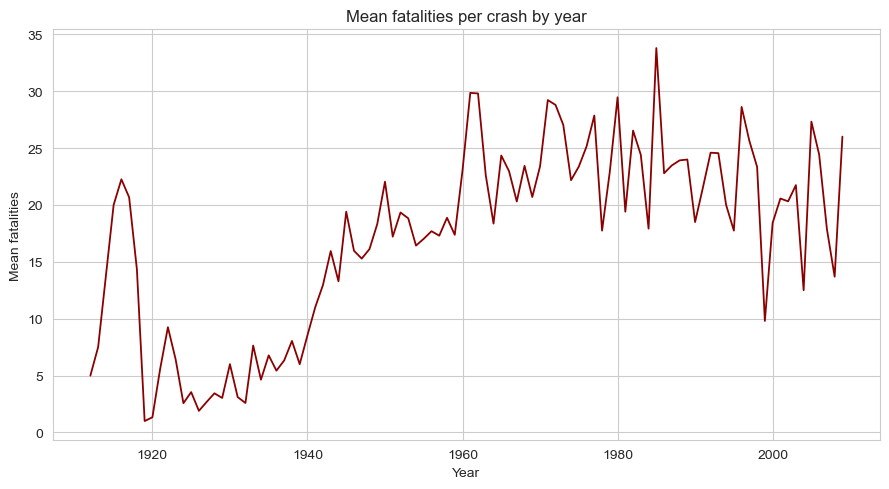

In [91]:
# mean fatalities per year over time
tmp = train.copy()
tmp['Year'] = pd.to_datetime(tmp['Date'], format='%m/%d/%Y', errors='coerce').dt.year
yearly = tmp.groupby('Year')['Fatalities'].mean()

plt.figure()
plt.plot(yearly.index, yearly.values, color='darkred', linewidth=1.3)
plt.title('Mean fatalities per crash by year')
plt.xlabel('Year')
plt.ylabel('Mean fatalities')
plt.tight_layout()
plt.show()

**Finding:** Average fatalities per crash generally increase over time, with some years showing noticeable peaks. This suggests that the date of an accident may provide useful information, so features such as `Year`, `Month`, and `Decade` will be extracted from the `Date` column.


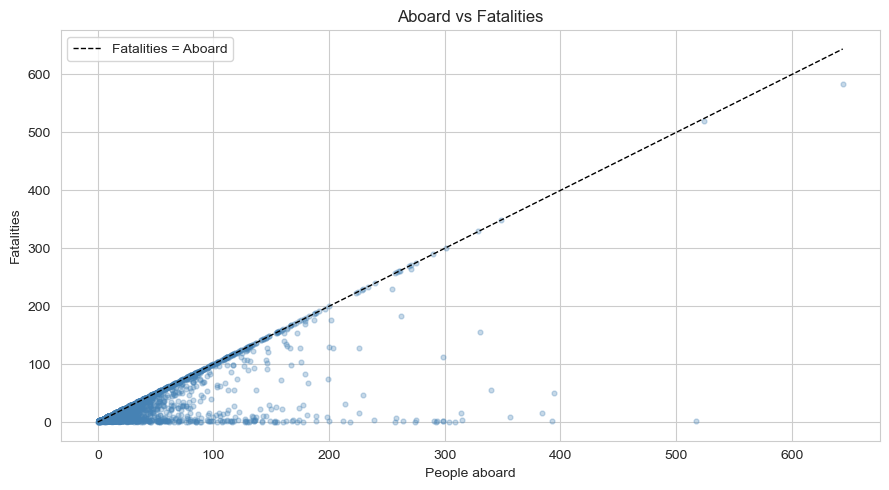

Pearson correlation Aboard vs Fatalities: 0.745


In [92]:
# relationship between 'people aboard' and 'fatalities'
plt.figure()
plt.scatter(train['Aboard'], train['Fatalities'], alpha=0.3, s=12, color='steelblue')
plt.plot([0, train['Aboard'].max()], [0, train['Aboard'].max()], color='black', linestyle='--', linewidth=1, label='Fatalities = Aboard')
plt.title('Aboard vs Fatalities')
plt.xlabel('People aboard')
plt.ylabel('Fatalities')
plt.legend()
plt.tight_layout()
plt.show()

print('Pearson correlation Aboard vs Fatalities:', round(train['Aboard'].corr(train['Fatalities']), 3))

**Findings:** `Aboard` shows a strong positive relationship with `Fatalities`, making it one of the most important predictors in the dataset. This is expected, as accidents involving more people on board have the potential to result in more fatalities. Therefore, this feature is retained for modelling.


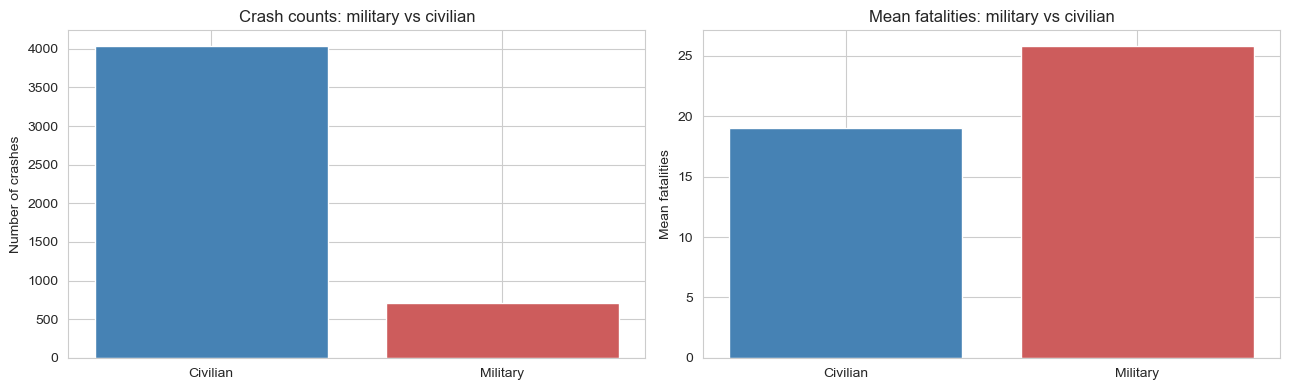

Share of military records: 14.9 %


In [93]:
# military vs civilian crash counts and fatalities mean
tmp = train.copy()
tmp['is_military'] = tmp['Operator'].fillna('').str.contains('Military', case=False).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
counts = tmp['is_military'].value_counts().sort_index()
ax[0].bar(['Civilian', 'Military'], counts.values, color=['steelblue', 'indianred'])
ax[0].set_title('Crash counts: military vs civilian')
ax[0].set_ylabel('Number of crashes')

means = tmp.groupby('is_military')['Fatalities'].mean()
ax[1].bar(['Civilian', 'Military'], means.values, color=['steelblue', 'indianred'])
ax[1].set_title('Mean fatalities: military vs civilian')
ax[1].set_ylabel('Mean fatalities')
plt.tight_layout()
plt.show()

print('Share of military records:', round(tmp['is_military'].mean() * 100, 1), '%')

**Findings:** Military accidents represent a relatively small portion of the dataset and tend to have fewer fatalities on average than civilian accidents. This suggests that the type of operator may influence the outcome of a crash, binary `is_military` feature is created from the `Operator` column.


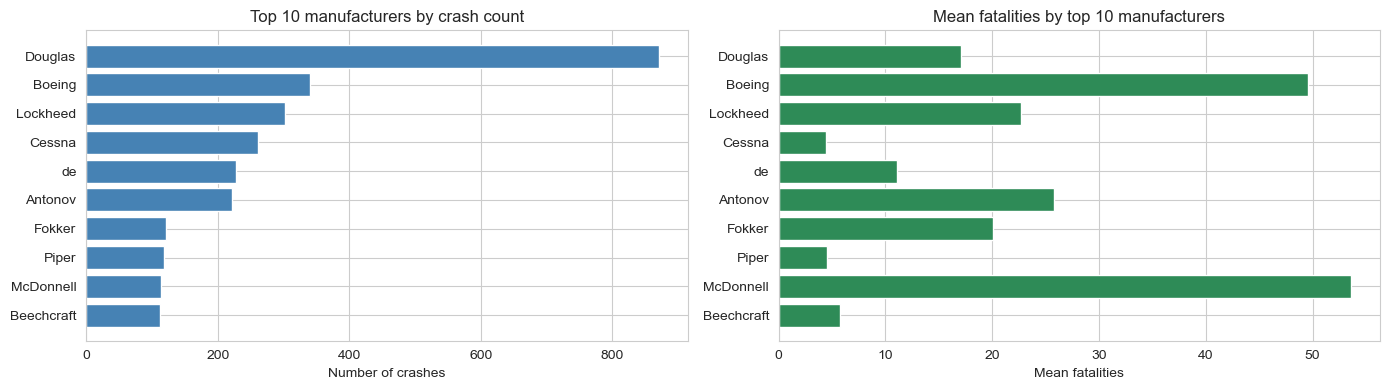

In [94]:
# top 10 aircraft manufacturers by crash count and fatalities mean
tmp = train.copy()
tmp['manufacturer'] = tmp['Type'].fillna('').str.split().str[0]
top10 = tmp['manufacturer'].value_counts().head(10)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].barh(top10.index[::-1], top10.values[::-1], color='steelblue')
ax[0].set_title('Top 10 manufacturers by crash count')
ax[0].set_xlabel('Number of crashes')

mean_by_man = tmp[tmp['manufacturer'].isin(top10.index)].groupby('manufacturer')['Fatalities'].mean().loc[top10.index]
ax[1].barh(mean_by_man.index[::-1], mean_by_man.values[::-1], color='seagreen')
ax[1].set_title('Mean fatalities by top 10 manufacturers')
ax[1].set_xlabel('Mean fatalities')
plt.tight_layout()
plt.show()

**Findings:** The number of crashes and average fatalities vary across aircraft manufacturers, suggesting that manufacturer information may be useful for prediction. However, the `Type` column contains many unique values, making it unsuitable for one-hot encoding.


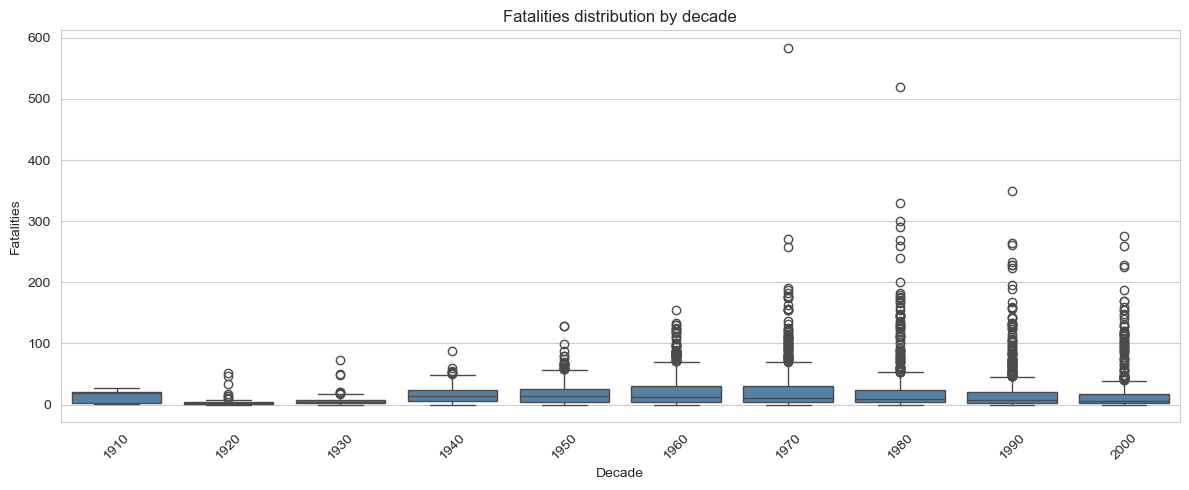

In [95]:
# box plot fatalities per decade (show spread)
tmp = train.copy()
tmp['Decade'] = (pd.to_datetime(tmp['Date'], format='%m/%d/%Y', errors='coerce').dt.year // 10) * 10
tmp = tmp.dropna(subset=['Decade', 'Fatalities'])
tmp['Decade'] = tmp['Decade'].astype(int)

plt.figure(figsize=(12, 5))
order = sorted(tmp['Decade'].unique())
sns.boxplot(x='Decade', y='Fatalities', data=tmp, order=order, color='steelblue')
plt.title('Fatalities distribution by decade')
plt.xlabel('Decade')
plt.ylabel('Fatalities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Findings:** Fatalities generally increase across later decades, suggesting that the period in which a crash occurred may influence the number of deaths. For this reason, a `Decade` feature is created to capture long-term trends in the data.


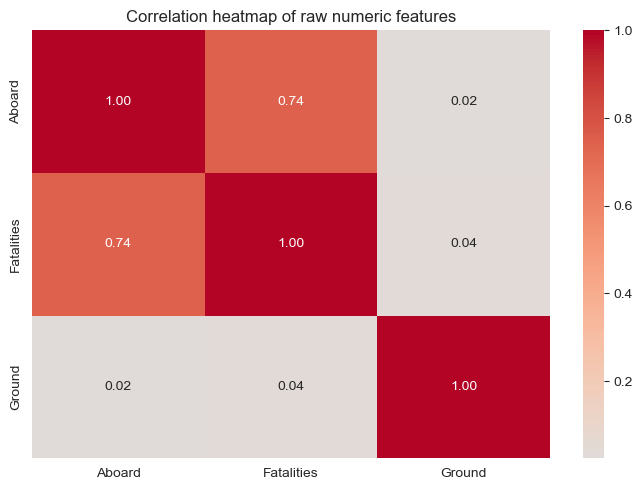

In [96]:
# correlation heatmap of numeric columns currently in the data
num_cols = train.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(7, 5))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap of raw numeric features')
plt.tight_layout()
plt.show()

**Findings:** Among the numerical features, `Aboard` shows the strongest relationship with `Fatalities`. Although `Ground` has a much weaker relationship, it is retained as it may still provide useful information for some crashes.


### The Ground outlier

In [97]:
# inspection of extreme ground value
print('Maximum Ground value:', train['Ground'].max())
print()
print(train.loc[train['Ground'] == train['Ground'].max(), ['Date', 'Location', 'Operator', 'Aboard', 'Fatalities', 'Ground']].to_string(index=False))

Maximum Ground value: 2750.0

      Date                Location          Operator  Aboard  Fatalities  Ground
09/11/2001 New York City, New York American Airlines    92.0        92.0  2750.0
09/11/2001 New York City, New York  United Air Lines    65.0        65.0  2750.0


**Findings:** The largest value in the `Ground` column is linked to the September 11, 2001 attacks. Although it is an extreme value, it represents a real event and is therefore retained in the dataset. Keeping this record helps preserve important information and avoids removing valid observations.


## Section 3: Data Preprocessing

This section prepares the data for modelling by cleaning the dataset, handling missing values, and creating new features. All preprocessing steps are applied consistently to both the training and unseen datasets. To avoid data leakage, any values learned from the training data are applied to the unseen data without refitting.


**Step 1: Remove rows with missing target values.**

Rows with missing `Fatalities` values are removed, as the target variable is required for model training.


In [98]:
# drop rows fatalities are missing, then reset index
print('Rows before:', len(train))
train = train.dropna(subset=['Fatalities']).reset_index(drop=True)
print('Rows after:', len(train))

Rows before: 4741
Rows after: 4730


**Step 2: Remove unused columns.**

Columns with a large number of missing values or limited usefulness for prediction are removed. This includes identifiers, highly sparse features, and free-text fields that are outside the scope of this analysis.

In [99]:
# columns to drop and why - both datasets.
drop_cols = ['Time', 'Flight #', 'Route', 'cn/In', 'Registration', 'Summary']
train = train.drop(columns=drop_cols)
unseen = unseen.drop(columns=drop_cols)
print('Remaining training columns:', list(train.columns))

Remaining training columns: ['Date', 'Location', 'Operator', 'Type', 'Aboard', 'Fatalities', 'Ground']


**Step 3: Create date-based features.**
The `Date` column is converted into useful numerical features, including `Year`, `Month`, and `Decade`. The original `Date` column - removed.

In [100]:
# analyse the date and build year, month and decade. then drop the raw date
def add_time_features(df):
    dt = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')
    df['Year'] = dt.dt.year
    df['Month'] = dt.dt.month
    df['Decade'] = (dt.dt.year // 10) * 10
    return df.drop(columns=['Date'])

train = add_time_features(train)
unseen = add_time_features(unseen)
train[['Year', 'Month', 'Decade']].head()

,Year,Month,Decade
0,1912,7,1910
1,1913,8,1910
2,1913,9,1910
3,1915,3,1910
4,1915,9,1910


**Step 4: Create an `is_military` feature.**
A binary feature is created from the `Operator` column to indicate whether a crash involved a military operator. The original `Operator` column - removed.


In [101]:
# binary military flag. drop the raw 0perator column.
def add_military_flag(df):
    df['is_military'] = df['Operator'].fillna('').str.contains('Military', case=False).astype(int)
    return df.drop(columns=['Operator'])

train = add_military_flag(train)
unseen = add_military_flag(unseen)
print('military share in training:', round(train['is_military'].mean() * 100, 1), '%')

military share in training: 14.9 %


**Step 5: Extract country information.**
A new `country` feature is extracted from the `Location` column to capture geographic information. The original `Location` column - removed.


In [ ]:
# country - last comma separated of location string
def add_country(df):
    df['country'] = df['Location'].fillna('').str.split(',').str[-1].str.strip()
    return df.drop(columns=['Location'])

train = add_country(train)
unseen = add_country(unseen)
print('distinct countries in training:', train['country'].nunique())

distinct countries in training: 474


**Step 6: Extract manufacturer information.**
A new `manufacturer` feature is created from the `Type` column to capture the aircraft manufacturer. The original `Type` column - removed.


In [103]:
# manufacturer - first word of aircraft type string
def add_manufacturer(df):
    df['manufacturer'] = df['Type'].fillna('').str.split().str[0]
    return df.drop(columns=['Type'])

train = add_manufacturer(train)
unseen = add_manufacturer(unseen)
print('distinct manufacturers in training:', train['manufacturer'].nunique())

distinct manufacturers in training: 281


**Step 7: Handle missing values.**
Any remaining missing values in `Aboard` and `Ground` are filled using the median value from the training data. reducing impact of extreme values and helps prevent data leakage.


In [104]:
# median imputation for aboard and ground + any stray missing time features
# medians are learnt from training - applied to both sets
aboard_med = train['Aboard'].median()
ground_med = train['Ground'].median()
year_med = train['Year'].median()
month_med = train['Month'].median()
decade_med = train['Decade'].median()

def impute(df):
    df['Aboard'] = df['Aboard'].fillna(aboard_med)
    df['Ground'] = df['Ground'].fillna(ground_med)
    df['Year'] = df['Year'].fillna(year_med)
    df['Month'] = df['Month'].fillna(month_med)
    df['Decade'] = df['Decade'].fillna(decade_med)
    return df

train = impute(train)
unseen = impute(unseen)
print('remaining missing values in training (excluding target):')
print(train.drop(columns=['Fatalities']).isnull().sum())

remaining missing values in training (excluding target):
Aboard           0
Ground           0
Year             0
Month            0
Decade           0
is_military      0
country          0
manufacturer    23
dtype: int64


**Step 8: Encode categorical features**

The `country` and `manufacturer` features are converted into numerical values using frequency encoding. keeping the dataset compact while preserving useful information about how common each category is


In [105]:
# build frequency maps on training data - apply to both sets
# unseen values -> 0

country_freq = train['country'].value_counts().to_dict()
manuf_freq   = train['manufacturer'].value_counts().to_dict()

def freq_encode(df):
    df['country'] = df['country'].map(country_freq).fillna(0).astype(float)
    df['manufacturer'] = df['manufacturer'].map(manuf_freq).fillna(0).astype(float)
    return df

train = freq_encode(train)
unseen = freq_encode(unseen)
train[['country', 'manufacturer']].head()

,country,manufacturer
0,38.0,3.0
1,132.0,111.0
2,1.0,12.0
3,17.0,12.0
4,68.0,12.0


**Step 9: Transform the target variable**

A `log1p` transformation is applied to `Fatalities` to reduce unbalance and improve model performance


In [107]:
# separate features and log-transformed fatalities
y = np.log1p(train['Fatalities'])
X = train.drop(columns=['Fatalities'])

# lock feature order
feature_names = list(X.columns)
unseen = unseen[feature_names]  

print('Feature columns:', feature_names)
print('X shape:', X.shape, '| y shape:', y.shape)
print('cleaned unseen shape:', unseen.shape)

Feature columns: ['Aboard', 'Ground', 'Year', 'Month', 'Decade', 'is_military', 'country', 'manufacturer']
X shape: (4730, 8) | y shape: (4730,)
cleaned unseen shape: (527, 8)


**Step 10: Scale the features**

The numerical features are standardised using `StandardScaler` to place them on a similar scale. The scaler is fitted using the training data only and then applied to the test and unseen datasets.


In [108]:
# summary before modelling
print('Final feature list:')
for i, f in enumerate(feature_names, 1):
    print(f'{i}. {f}')
print()
print('cleaned training feature matrix shape:', X.shape)
print('target vector shape:', y.shape)
X.head()

Final feature list:
1. Aboard
2. Ground
3. Year
4. Month
5. Decade
6. is_military
7. country
8. manufacturer

cleaned training feature matrix shape: (4730, 8)
target vector shape: (4730,)


,Aboard,Ground,Year,Month,Decade,is_military,country,manufacturer
0,5.0,0.0,1912,7,1910,1,38.0,3.0
1,1.0,0.0,1913,8,1910,0,132.0,111.0
2,20.0,0.0,1913,9,1910,1,1.0,12.0
3,41.0,0.0,1915,3,1910,1,17.0,12.0
4,19.0,0.0,1915,9,1910,1,68.0,12.0
